In [308]:
import torch
import matplotlib.pyplot as plt 
from icecream import ic

In [309]:
X = torch.linspace(0, 10, 100).reshape(-1, 1)
y = 2*X + 3 + 10*torch.rand(X.shape)

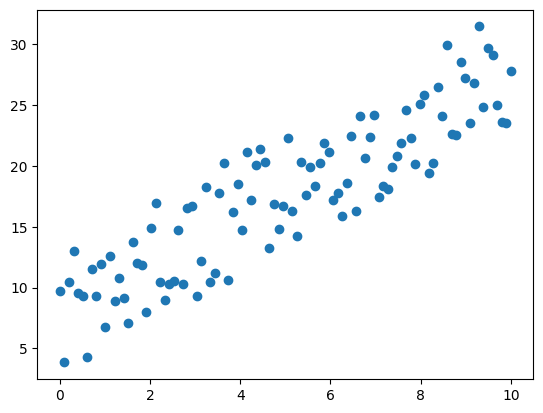

In [310]:
plt.scatter(X, y)

In [311]:
def lin_reg(X, w, b):
    return X * w + b

In [312]:
w = torch.rand(1, requires_grad=True)
b = torch.rand(1, requires_grad=True)

In [313]:
def loss_fn(y_pred, y):
    return ((y_pred - y) ** 2).mean()

In [314]:
lr = 0.01
y_pred = lin_reg(X, w, b)
loss = loss_fn(y_pred, y)
loss.backward()
with torch.no_grad():
    w -= ic(lr * w.grad)
    b -= lr * b.grad

w.grad.zero_()
b.grad.zero_()

ic| lr * w.grad: tensor([-1.8557])


tensor([0.])

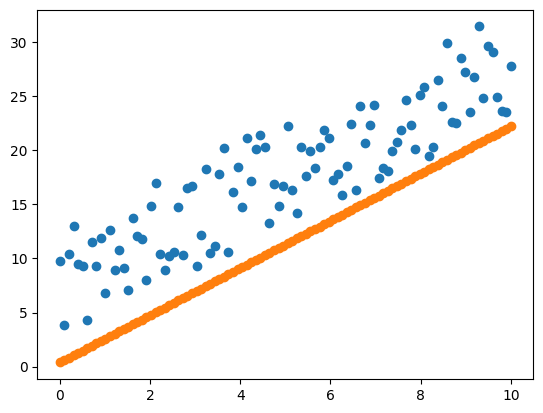

In [315]:
with torch.no_grad():
    plt.scatter(X, y)
    plt.scatter(X, lin_reg(X, 
                           w, b))


TypeError: Input z must be 2D, not 1D

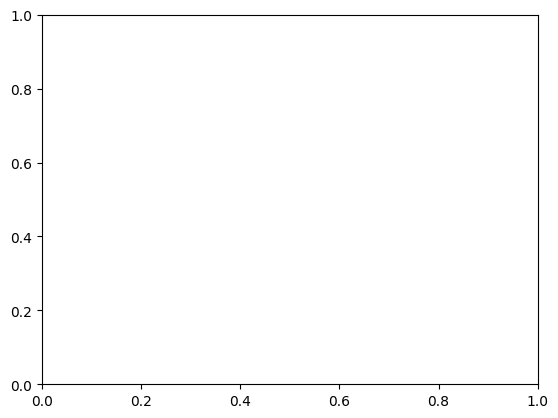

In [ ]:
ws = torch.linspace(-10, 10, 100)
bs = torch.linspace(-10, 10, 100)
WW, BB = torch.meshgrid(ws, bs)

Y_pred = X.squeeze() @ WW.unsqueeze(-1) + BB.unsqueeze(-1)

plt.contour(WW, BB, (y - Y_pred.squeeze()).pow(2).mean(-1))